# 🌟 Master Notebook: Alur Lengkap EDA & Preprocessing Teks
**Proyek:** Sistem Rekomendasi & Analisis Sentimen Pariwisata Kabupaten Garut  
**Deskripsi:**
Notebook ini merangkum seluruh alur *Exploratory Data Analysis* (EDA) dan *Text Preprocessing* dari data mentah (*raw*) hingga dataset bersih siap latih machine learning secara menyeluruh dalam satu alur terpadu yang kaya akan **Tabel Perbandingan Sebelum vs Sesudah (Before & After)**.

### Alur Utama Pipeline:
1. **Bagian 1: Pemuatan Data, Penggabungan, Deduplikasi, & Validasi**
2. **Bagian 2: Rangkaian Text Preprocessing 5 Tahap (Cleaning, Case Folding, Tokenize, Stopwords, Stemming)**
3. **Bagian 3: Filter Teks Kosong Pasca Preprocessing & Corong Data**
4. **Bagian 4: Pelabelan Sentimen Berbasis Rating (Positif, Netral, Negatif)**
5. **Bagian 5: Analisis Leksikal, WordCloud, & Top N-Grams**
6. **Bagian 6: Analisis Sentimen per Destinasi Wisata**


In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings
from config.constants import CUSTOM_INDONESIAN_STOPWORDS
from preprocessing.cleaning import clean_text
from preprocessing.case_folding import case_folding
from preprocessing.tokenization import tokenize
from preprocessing.stopword_removal import remove_stopwords, ALL_STOPWORDS
from preprocessing.stemming import stem_tokens
from sentiment.labeling import apply_sentiment_labeling, get_label_from_rating

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Seluruh modul & konfigurasi berhasil diimpor.")


✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Seluruh modul & konfigurasi berhasil diimpor.


## 1. Pemuatan Data, Penggabungan, Deduplikasi, & Validasi

In [2]:
# 1. Pemuatan Data
df_orig = pd.read_csv(settings.RAW_DATA_DIR / "reviews.csv")
repaired_path = settings.RAW_DATA_DIR / "reviews_repaired.csv"
df_rep = pd.read_csv(repaired_path) if repaired_path.exists() else pd.DataFrame()

# 2. Penggabungan dengan prioritas repaired
df_orig["_source"] = "original"
if not df_rep.empty:
    df_rep["_source"] = "repaired"
    df_merged = pd.concat([df_rep, df_orig], ignore_index=True)
else:
    df_merged = df_orig.copy()

total_raw_merged = len(df_merged)

# 3. Deduplikasi Composite Key
composite_cols = ["destination_name", "author", "review_date", "review_text"]
df_temp = df_merged.fillna({col: "" for col in composite_cols})
dup_mask = df_temp.duplicated(subset=composite_cols, keep="first")
duplicate_count = dup_mask.sum()
df_dedup = df_merged[~dup_mask].copy().drop(columns=["_source"], errors="ignore")
total_dedup = len(df_dedup)

# 4. Filter Kualitas
df_valid = df_dedup.dropna(subset=["review_text"])
df_valid = df_valid[df_valid["review_text"].astype(str).str.strip() != ""]
after_text_filter = len(df_valid)

df_valid = df_valid.dropna(subset=["destination_name"])
df_valid = df_valid[df_valid["destination_name"].astype(str).str.strip() != ""]
after_dest_filter = len(df_valid)

def is_valid_rating(r):
    try:
        val = float(r)
        return 1.0 <= val <= 5.0
    except (ValueError, TypeError):
        return False

valid_rating_mask = df_valid["rating"].apply(is_valid_rating)
df_valid = df_valid[valid_rating_mask].copy()
df_valid["rating"] = df_valid["rating"].astype(float)
total_valid = len(df_valid)

# TABEL REKAPITULASI SEBELUM VS SESUDAH FILTERING AWAL
rekap_tahap1 = pd.DataFrame([
    {"Tahap": "1. Data Mentah Gabungan (Raw Merged)", "Jumlah Baris": f"{total_raw_merged:,}", "Baris Berkurang": "0", "Persentase Sisa": "100.0%"},
    {"Tahap": "2. Pembersihan Duplikat (Composite Key)", "Jumlah Baris": f"{total_dedup:,}", "Baris Berkurang": f"-{duplicate_count:,}", "Persentase Sisa": f"{(total_dedup/total_raw_merged)*100:.2f}%"},
    {"Tahap": "3. Filter Teks Ulasan Kosong", "Jumlah Baris": f"{after_text_filter:,}", "Baris Berkurang": f"-{total_dedup - after_text_filter:,}", "Persentase Sisa": f"{(after_text_filter/total_raw_merged)*100:.2f}%"},
    {"Tahap": "4. Filter Destinasi Kosong", "Jumlah Baris": f"{after_dest_filter:,}", "Baris Berkurang": f"-{after_text_filter - after_dest_filter:,}", "Persentase Sisa": f"{(after_dest_filter/total_raw_merged)*100:.2f}%"},
    {"Tahap": "5. Filter Validitas Rating (1.0-5.0)", "Jumlah Baris": f"{total_valid:,}", "Baris Berkurang": f"-{after_dest_filter - total_valid:,}", "Persentase Sisa": f"{(total_valid/total_raw_merged)*100:.2f}%"}
])
display(rekap_tahap1)


,Tahap,Jumlah Baris,Baris Berkurang,Persentase Sisa
0,1. Data Mentah Gabungan (Raw Merged),"36,574",0,100.0%
1,2. Pembersihan Duplikat (Composite Key),"34,240","-2,334",93.62%
2,3. Filter Teks Ulasan Kosong,"19,702","-14,538",53.87%
3,4. Filter Destinasi Kosong,"19,702",-0,53.87%
4,5. Filter Validitas Rating (1.0-5.0),"18,124","-1,578",49.55%


## 2. Rangkaian Preprocessing Teks (5 Tahapan)

In [3]:
# 1. Text Cleaning
df_valid["clean_step1"] = df_valid["review_text"].apply(clean_text)

# 2. Case Folding
df_valid["clean_step2"] = df_valid["clean_step1"].apply(case_folding)

# 3. Tokenization
df_valid["clean_step3_tokens"] = df_valid["clean_step2"].apply(tokenize)

# 4. Stopword Removal
df_valid["clean_step4_tokens"] = df_valid["clean_step3_tokens"].apply(remove_stopwords)

# 5. Stemming (PySastrawi)
tqdm.pandas(desc="Menjalankan Stemming")
df_valid["clean_step5_tokens"] = df_valid["clean_step4_tokens"].progress_apply(stem_tokens)

# Gabung kembali menjadi string
df_valid["cleaned_text"] = df_valid["clean_step5_tokens"].apply(lambda t: " ".join(t))

# 6. Filter Ulasan Kosong Pasca Preprocessing
total_before_empty = len(df_valid)
df_clean_final = df_valid[df_valid["cleaned_text"].str.strip() != ""].copy()
total_clean_final = len(df_clean_final)
empty_reviews_removed = total_before_empty - total_clean_final

# TABEL PERBANDINGAN PREPROCESSING TAHAP AKHIR
tabel_funnel_prep = pd.DataFrame([
    {"Tahap": "Total Ulasan Masuk Preprocessing", "Jumlah Baris": f"{total_before_empty:,}", "Keterangan": "Data tervalidasi"},
    {"Tahap": "Ulasan Menjadi Kosong (Hanya Stopwords)", "Jumlah Baris": f"-{empty_reviews_removed:,}", "Keterangan": f"Dihapus ({empty_reviews_removed/total_before_empty*100:.2f}%)"},
    {"Tahap": "Ulasan BERSIH FINAL (Siap ML)", "Jumlah Baris": f"{total_clean_final:,}", "Keterangan": "Output bersih siap latih"}
])
display(tabel_funnel_prep)


Menjalankan Stemming:   0%|          | 0/18124 [00:00<?, ?it/s]

Menjalankan Stemming:   2%|▏         | 323/18124 [00:00<00:05, 3218.64it/s]

Menjalankan Stemming:   4%|▍         | 787/18124 [00:00<00:04, 4043.73it/s]

Menjalankan Stemming:   9%|▉         | 1666/18124 [00:00<00:02, 6200.77it/s]

Menjalankan Stemming:  14%|█▍        | 2598/18124 [00:00<00:02, 7426.77it/s]

...

Menjalankan Stemming:  79%|███████▉  | 14332/18124 [00:01<00:00, 13891.18it/s]

Menjalankan Stemming:  88%|████████▊ | 16010/18124 [00:01<00:00, 14716.95it/s]

Menjalankan Stemming:  99%|█████████▊| 17867/18124 [00:01<00:00, 15817.44it/s]

Menjalankan Stemming: 100%|██████████| 18124/18124 [00:01<00:00, 11162.45it/s]

,Tahap,Jumlah Baris,Keterangan
0,Total Ulasan Masuk Preprocessing,"18,124",Data tervalidasi
1,Ulasan Menjadi Kosong (Hanya Stopwords),-201,Dihapus (1.11%)
2,Ulasan BERSIH FINAL (Siap ML),"17,923",Output bersih siap latih


In [4]:
# TABEL PERBANDINGAN SEBELUM VS SESUDAH PREPROCESSING (5 SAMPEL)
sample_view = df_clean_final.sample(5, random_state=42)

tabel_before_after = pd.DataFrame({
    "No": range(1, 6),
    "Teks Sebelum Preprocessing (Raw)": sample_view["review_text"].values,
    "Teks Sesudah Preprocessing (Cleaned & Stemmed)": sample_view["cleaned_text"].values
})
display(tabel_before_after)


,No,Teks Sebelum Preprocessing (Raw),Teks Sesudah Preprocessing (Cleaned & Stemmed)
0,1,Bagus,bagus
1,2,Nyaman buat kemping,nyaman kemping
2,3,Tempat nyaman utk beristirahat,nyaman istirahat
3,4,"Kampung Muara Sunda Garut menawarkan suasana yang sangat aesthetic dan sejuk, cocok sekali untuk makan bersama keluarga sambil menikmati udara asri. Rasa makanannya pun cukup enak dengan bumbu Sunda yang pas. Namun, jika kondisi restoran sedang penuh, pelayanannya terasa cukup lama, jadi disarankan datang lebih awal atau saat tidak sedang terburu-buru agar tetap nyaman..",kampung muara sunda tawar suasana aesthetic sejuk cocok makan keluarga nikmat udara asri makan enak bumbu sunda pas kondisi restoran penuh layan saran buru buru nyaman
4,5,"Saya datang ke sini untuk sarapan sekitar jam 8 pagi dan jujur ​​saja, saya sama sekali tidak kecewa. Makanannya luar biasa, favorit saya adalah roti bakar, benar-benar lezat. Pemandangannya membuat sarapan saya semakin sempurna. Untungnya hari itu langit lebih cerah dari biasanya. Pengalaman 10/10.",sarap jam 8 pagi jujur kecewa makan favorit roti bakar lezat pandang sarap sempurna untung langit cerah alam 10 10


## 3. Pelabelan Sentimen & Analisis Distribusi

In [5]:
df_clean_final = apply_sentiment_labeling(df_clean_final)
sentiment_names = {0: "Negatif", 1: "Netral", 2: "Positif"}
df_clean_final["sentiment_name"] = df_clean_final["sentiment_label"].map(sentiment_names)

# TABEL DISTRIBUSI SENTIMEN
s_counts = df_clean_final["sentiment_name"].value_counts().reindex(["Positif", "Netral", "Negatif"])
tabel_sent = pd.DataFrame({
    "Sentimen": s_counts.index,
    "Rentang Rating": ["4.0 - 5.0 Bintang", "3.0 Bintang", "1.0 - 2.0 Bintang"],
    "Jumlah Ulasan": [f"{v:,}" for v in s_counts.values],
    "Persentase": [f"{(v/len(df_clean_final))*100:.2f}%" for v in s_counts.values]
})
display(tabel_sent)


,Sentimen,Rentang Rating,Jumlah Ulasan,Persentase
0,Positif,4.0 - 5.0 Bintang,"15,553",86.78%
1,Netral,3.0 Bintang,819,4.57%
2,Negatif,1.0 - 2.0 Bintang,"1,551",8.65%


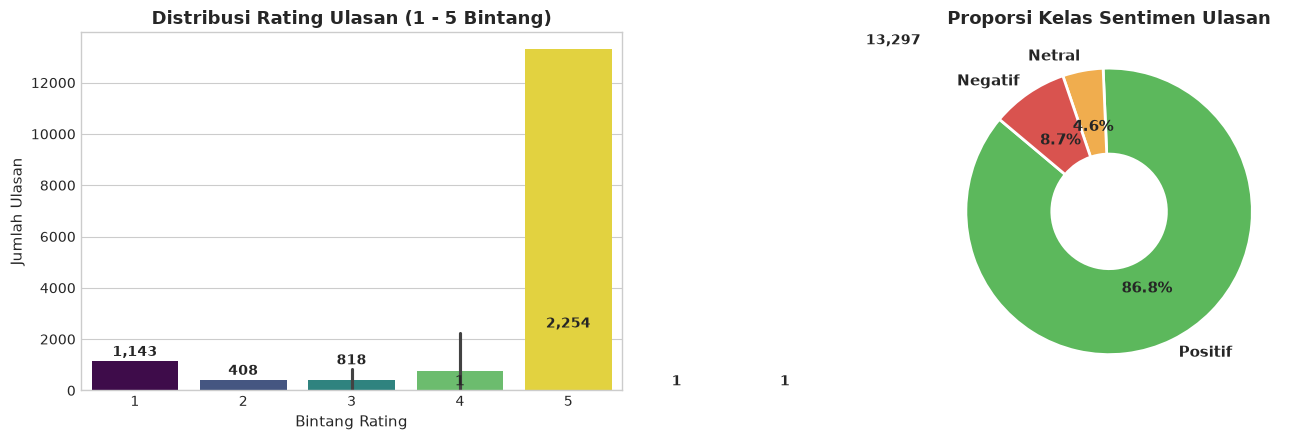

In [6]:
# Visualisasi Distribusi Rating & Sentimen
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=100)

r_counts = df_clean_final["rating"].value_counts().sort_index()
sns.barplot(x=r_counts.index.astype(int), y=r_counts.values, hue=r_counts.index.astype(int), legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Distribusi Rating Ulasan (1 - 5 Bintang)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Bintang Rating", fontsize=11)
axes[0].set_ylabel("Jumlah Ulasan", fontsize=11)
for i, v in enumerate(r_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold", fontsize=10)

colors = ["#5cb85c", "#f0ad4e", "#d9534f"]
axes[1].pie(
    s_counts.values, 
    labels=s_counts.index, 
    autopct="%1.1f%%", 
    startangle=140, 
    colors=colors,
    wedgeprops=dict(width=0.6, edgecolor='w', linewidth=2),
    textprops=dict(fontsize=11, fontweight="bold")
)
axes[1].set_title("Proporsi Kelas Sentimen Ulasan", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Visualisasi WordCloud

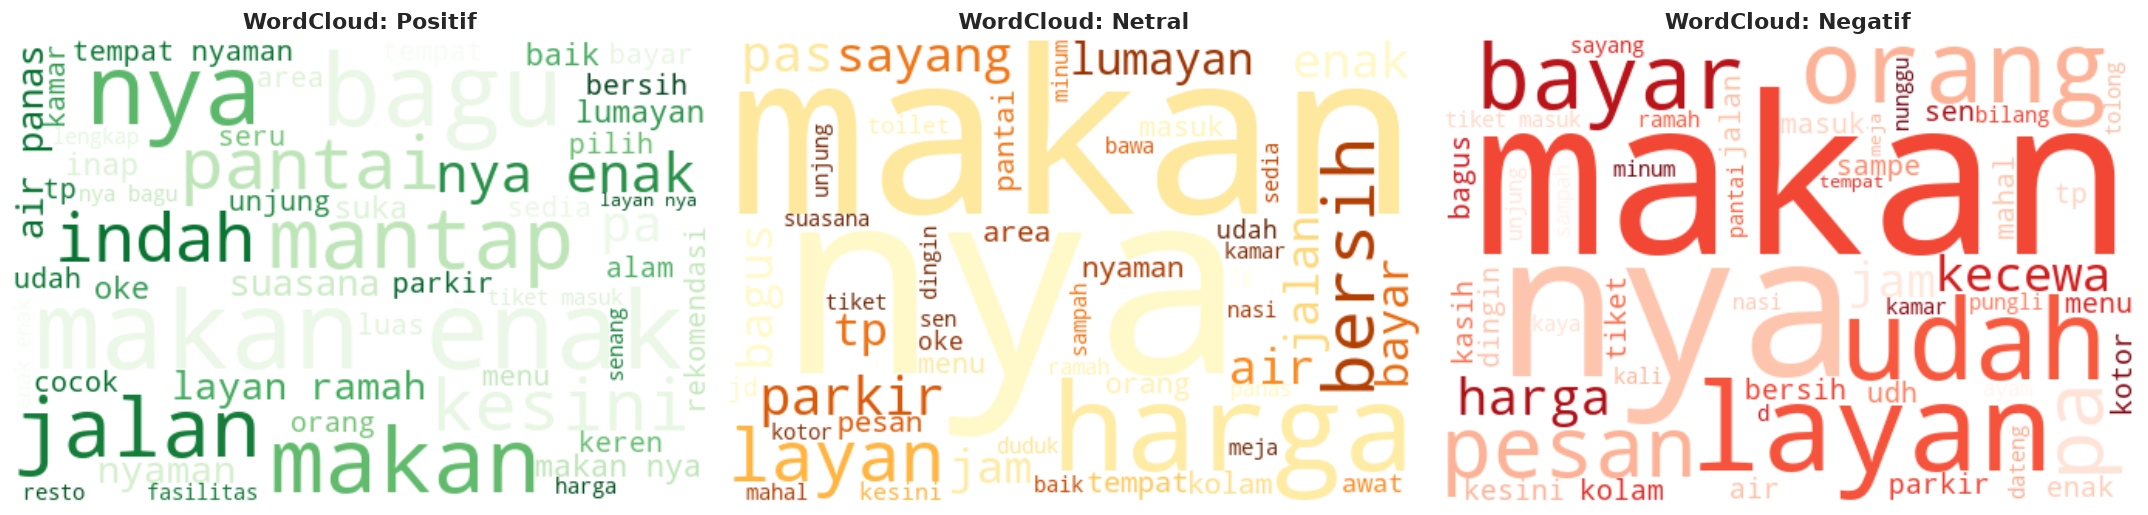

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
for ax, (label_name, cmap, l_val) in zip(axes, [("Positif", "Greens", 2), ("Netral", "YlOrBr", 1), ("Negatif", "Reds", 0)]):
    text = " ".join(df_clean_final[df_clean_final["sentiment_label"] == l_val]["cleaned_text"])
    wc = WordCloud(width=450, height=300, background_color="white", colormap=cmap, max_words=50, random_state=42).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"WordCloud: {label_name}", fontsize=13, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Tabel Top Kata Kunci (Unigram & Bigram)

In [8]:
def get_top_ngrams(corpus, ngram_range=(1, 1), top_n=8):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return pd.DataFrame(sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n], columns=["Kata", "Freq"])

uni_pos = get_top_ngrams(df_clean_final[df_clean_final["sentiment_label"] == 2]["cleaned_text"], (1, 1), 8)
uni_neg = get_top_ngrams(df_clean_final[df_clean_final["sentiment_label"] == 0]["cleaned_text"], (1, 1), 8)

tabel_top_words = pd.DataFrame({
    "Top Kata Positif": uni_pos["Kata"], "Freq Pos": uni_pos["Freq"],
    "Top Kata Negatif (Keluhan)": uni_neg["Kata"], "Freq Neg": uni_neg["Freq"]
})
display(tabel_top_words)


,Top Kata Positif,Freq Pos,Top Kata Negatif (Keluhan),Freq Neg
0,makan,5587,makan,869
1,nya,4786,nya,660
2,enak,4587,layan,401
3,bagus,2526,jam,333
4,nyaman,2377,bayar,275
5,tempat,1978,masuk,254
6,layan,1849,udah,240
7,pantai,1792,tiket,234


## 6. Penyimpanan Data Final Siap Latih Machine Learning

In [9]:
export_cols = ["destination_name", "author", "rating", "review_text", "cleaned_text", "sentiment_label", "sentiment_name"]
output_path = settings.FINAL_DATA_DIR / "labeled_reviews.csv"
df_clean_final[export_cols].to_csv(output_path, index=False)
print(f"✅ Pipeline Master Selesai! Data final disimpan di: {output_path}")
print(f"Total baris data bersih final: {len(df_clean_final):,} ulasan.")


✅ Pipeline Master Selesai! Data final disimpan di: /Users/macbook/Garut-Tourism-Reccomendation/data/final/labeled_reviews.csv
Total baris data bersih final: 17,923 ulasan.
